### B1 Pipeline : Technical Indicators Only

In [15]:
import polars as pl
import numpy as np
import os, joblib, pickle
from datetime import date
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
)
import matplotlib.pyplot as plt

In [16]:
Model_path = "data/tech_modeling_table.parquet"

df_model = pl.read_parquet(Model_path)
print(f"Shape: {df_model.shape}")
print(f"Target direction distribution:\n{df_model['target_direction'].value_counts().sort('target_direction')}")

Shape: (24048, 225)
Target direction distribution:
shape: (2, 2)
┌──────────────────┬───────┐
│ target_direction ┆ count │
│ ---              ┆ ---   │
│ i64              ┆ u32   │
╞══════════════════╪═══════╡
│ 0                ┆ 11451 │
│ 1                ┆ 12597 │
└──────────────────┴───────┘


In [17]:
TRAIN_WINDOW = 7
FOLDS = [
    (date(y - TRAIN_WINDOW, 1, 1), date(y, 1, 1), date(y + 1, 1, 1))
    for y in range(2021, 2026)
]

feature_cols = [c for c in df_model.columns
                if c not in ["symbol", "earnings_date", "entry_price", "target_return",
                             "target_direction", "max_high", "min_high", "max_day", "min_day"]]

folds_data = []

for fold_num, (train_start, test_start, test_end) in enumerate(FOLDS, 1):
    train = df_model.filter(
        (pl.col("earnings_date") >= train_start) & (pl.col("earnings_date") < test_start)
    )
    test = df_model.filter(
        (pl.col("earnings_date") >= test_start) & (pl.col("earnings_date") < test_end)
    )

    X_train = train.select(feature_cols).to_numpy()
    X_test = test.select(feature_cols).to_numpy()

    X_train = np.where(np.isinf(X_train), np.nan, X_train)
    X_test = np.where(np.isinf(X_test), np.nan, X_test)
    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    folds_data.append({
        "fold_num": fold_num,
        "train_years": f"{train_start.year}-{test_start.year - 1}",
        "test_year": test_start.year,
        "X_train": X_train, "X_test": X_test,
        "X_train_sc": X_train_sc, "X_test_sc": X_test_sc,
        "y_train_cls": train["target_direction"].to_numpy(),
        "y_test_cls": test["target_direction"].to_numpy(),
        "y_train_ret": train["target_return"].to_numpy(),
        "y_test_ret": test["target_return"].to_numpy(),
    })

    print(f"Fold {fold_num}: train [{train_start.year}-{test_start.year-1}] "
          f"({len(X_train):,}) → test [{test_start.year}] ({len(X_test):,})")

Fold 1: train [2014-2020] (13,169) → test [2021] (1,970)
Fold 2: train [2015-2021] (13,313) → test [2022] (1,975)
Fold 3: train [2016-2022] (13,439) → test [2023] (1,984)
Fold 4: train [2017-2023] (13,560) → test [2024] (2,000)
Fold 5: train [2018-2024] (13,671) → test [2025] (2,008)


In [18]:
np.random.seed(42)

b0_clf = {"fold_acc": [], "preds": [], "true": []}
b0_reg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}

for f in folds_data:
    preds_cls = np.random.randint(0, 2, size=len(f["y_test_cls"]))
    acc = accuracy_score(f["y_test_cls"], preds_cls)
    b0_clf["fold_acc"].append(acc)
    b0_clf["preds"].extend(preds_cls)
    b0_clf["true"].extend(f["y_test_cls"])

    preds_ret = np.full(len(f["y_test_ret"]), f["y_train_ret"].mean())
    b0_reg["fold_mae"].append(mean_absolute_error(f["y_test_ret"], preds_ret))
    b0_reg["fold_rmse"].append(np.sqrt(mean_squared_error(f["y_test_ret"], preds_ret)))
    b0_reg["preds"].extend(preds_ret)
    b0_reg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']}: DA={acc:.4f}")

print(f"\nAvg DA:   {np.mean(b0_clf['fold_acc']):.4f}")
print(f"Avg MAE:  {np.mean(b0_reg['fold_mae']):.4f}")
print(f"Avg RMSE: {np.mean(b0_reg['fold_rmse']):.4f}")

Fold 1: DA=0.4904
Fold 2: DA=0.5068
Fold 3: DA=0.5040
Fold 4: DA=0.4935
Fold 5: DA=0.5030

Avg DA:   0.4995
Avg MAE:  0.0310
Avg RMSE: 0.0458


In [19]:
lr_clf = {"fold_acc": [], "preds": [], "probs": [], "true": []}
lr_model = LogisticRegression(max_iter=1000, class_weight="balanced")

for f in folds_data:
    lr_model.fit(f["X_train_sc"], f["y_train_cls"])
    preds = lr_model.predict(f["X_test_sc"])
    probs = lr_model.predict_proba(f["X_test_sc"])[:, 1]

    acc = accuracy_score(f["y_test_cls"], preds)
    lr_clf["fold_acc"].append(acc)
    lr_clf["preds"].extend(preds)
    lr_clf["probs"].extend(probs)
    lr_clf["true"].extend(f["y_test_cls"])

    print(f"Fold {f['fold_num']} [{f['test_year']}]: DA={acc:.4f}")

true = np.array(lr_clf["true"])
preds = np.array(lr_clf["preds"])
print(f"\nAvg DA:     {np.mean(lr_clf['fold_acc']):.4f}")
print(f"Pooled F1:  {f1_score(true, preds, average='weighted'):.4f}")
print(f"Precision:  {precision_score(true, preds, average='weighted'):.4f}")
print(f"Recall:     {recall_score(true, preds, average='weighted'):.4f}")
print(f"Pooled AUC: {roc_auc_score(true, np.array(lr_clf['probs'])):.4f}")

Fold 1 [2021]: DA=0.5721
Fold 2 [2022]: DA=0.6122
Fold 3 [2023]: DA=0.5756
Fold 4 [2024]: DA=0.5265
Fold 5 [2025]: DA=0.5817

Avg DA:     0.5736
Pooled F1:  0.5751
Precision:  0.5783
Recall:     0.5735
Pooled AUC: 0.6035


In [20]:
linreg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
linreg_model = LinearRegression()

for f in folds_data:
    linreg_model.fit(f["X_train_sc"], f["y_train_ret"])
    preds = linreg_model.predict(f["X_test_sc"])

    mae = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    linreg["fold_mae"].append(mae)
    linreg["fold_rmse"].append(rmse)
    linreg["preds"].extend(preds)
    linreg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']} [{f['test_year']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nAvg MAE:   {np.mean(linreg['fold_mae']):.4f}")
print(f"Avg RMSE:  {np.mean(linreg['fold_rmse']):.4f}")
print(f"Pooled R²: {r2_score(np.array(linreg['true']), np.array(linreg['preds'])):.4f}")

Fold 1 [2021]: MAE=0.0285  RMSE=0.0407
Fold 2 [2022]: MAE=0.0357  RMSE=0.0507
Fold 3 [2023]: MAE=0.0276  RMSE=0.0393
Fold 4 [2024]: MAE=0.0323  RMSE=0.1469
Fold 5 [2025]: MAE=0.0517  RMSE=0.9498

Avg MAE:   0.0352
Avg RMSE:  0.2455
Pooled R²: -88.7067


In [21]:
rf_clf = {"fold_acc": [], "preds": [], "probs": [], "true": []}
rf_clf_model = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight="balanced", random_state=42, n_jobs=-1)

for f in folds_data:
    rf_clf_model.fit(f["X_train"], f["y_train_cls"])
    preds = rf_clf_model.predict(f["X_test"])
    probs = rf_clf_model.predict_proba(f["X_test"])[:, 1]

    acc = accuracy_score(f["y_test_cls"], preds)
    rf_clf["fold_acc"].append(acc)
    rf_clf["preds"].extend(preds)
    rf_clf["probs"].extend(probs)
    rf_clf["true"].extend(f["y_test_cls"])

    print(f"Fold {f['fold_num']} [{f['test_year']}]: DA={acc:.4f}")

true = np.array(rf_clf["true"])
preds = np.array(rf_clf["preds"])
print(f"\nAvg DA:     {np.mean(rf_clf['fold_acc']):.4f}")
print(f"Pooled F1:  {f1_score(true, preds, average='weighted'):.4f}")
print(f"Precision:  {precision_score(true, preds, average='weighted'):.4f}")
print(f"Recall:     {recall_score(true, preds, average='weighted'):.4f}")
print(f"Pooled AUC: {roc_auc_score(true, np.array(rf_clf['probs'])):.4f}")

Fold 1 [2021]: DA=0.5766
Fold 2 [2022]: DA=0.6446
Fold 3 [2023]: DA=0.5988
Fold 4 [2024]: DA=0.5365
Fold 5 [2025]: DA=0.5916

Avg DA:     0.5896
Pooled F1:  0.5877
Precision:  0.5867
Recall:     0.5895
Pooled AUC: 0.6192


In [22]:
rf_reg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
rf_reg_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

for f in folds_data:
    rf_reg_model.fit(f["X_train"], f["y_train_ret"])
    preds = rf_reg_model.predict(f["X_test"])

    mae = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    rf_reg["fold_mae"].append(mae)
    rf_reg["fold_rmse"].append(rmse)
    rf_reg["preds"].extend(preds)
    rf_reg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']} [{f['test_year']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nAvg MAE:   {np.mean(rf_reg['fold_mae']):.4f}")
print(f"Avg RMSE:  {np.mean(rf_reg['fold_rmse']):.4f}")
print(f"Pooled R²: {r2_score(np.array(rf_reg['true']), np.array(rf_reg['preds'])):.4f}")

Fold 1 [2021]: MAE=0.0280  RMSE=0.0395
Fold 2 [2022]: MAE=0.0356  RMSE=0.0490
Fold 3 [2023]: MAE=0.0262  RMSE=0.0366
Fold 4 [2024]: MAE=0.0284  RMSE=0.0440
Fold 5 [2025]: MAE=0.0300  RMSE=0.0443

Avg MAE:   0.0296
Avg RMSE:  0.0427
Pooled R²: 0.1208


In [23]:
xgb_clf = {"fold_acc": [], "preds": [], "probs": [], "true": []}
xgb_clf_model = XGBClassifier(n_estimators=200, eval_metric="logloss", random_state=42)

for f in folds_data:
    xgb_clf_model.fit(f["X_train"], f["y_train_cls"])
    preds = xgb_clf_model.predict(f["X_test"])
    probs = xgb_clf_model.predict_proba(f["X_test"])[:, 1]

    acc = accuracy_score(f["y_test_cls"], preds)
    xgb_clf["fold_acc"].append(acc)
    xgb_clf["preds"].extend(preds)
    xgb_clf["probs"].extend(probs)
    xgb_clf["true"].extend(f["y_test_cls"])

    print(f"Fold {f['fold_num']} [{f['test_year']}]: DA={acc:.4f}")

true = np.array(xgb_clf["true"])
preds = np.array(xgb_clf["preds"])
print(f"\nAvg DA:     {np.mean(xgb_clf['fold_acc']):.4f}")
print(f"Pooled F1:  {f1_score(true, preds, average='weighted'):.4f}")
print(f"Precision:  {precision_score(true, preds, average='weighted'):.4f}")
print(f"Recall:     {recall_score(true, preds, average='weighted'):.4f}")
print(f"Pooled AUC: {roc_auc_score(true, np.array(xgb_clf['probs'])):.4f}")

Fold 1 [2021]: DA=0.5645
Fold 2 [2022]: DA=0.5975
Fold 3 [2023]: DA=0.5817
Fold 4 [2024]: DA=0.5445
Fold 5 [2025]: DA=0.5558

Avg DA:     0.5688
Pooled F1:  0.5654
Precision:  0.5640
Recall:     0.5687
Pooled AUC: 0.5844


In [24]:
xgb_reg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
xgb_reg_model = XGBRegressor(n_estimators=200, random_state=42)

for f in folds_data:
    xgb_reg_model.fit(f["X_train"], f["y_train_ret"])
    preds = xgb_reg_model.predict(f["X_test"])

    mae = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    xgb_reg["fold_mae"].append(mae)
    xgb_reg["fold_rmse"].append(rmse)
    xgb_reg["preds"].extend(preds)
    xgb_reg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']} [{f['test_year']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nAvg MAE:   {np.mean(xgb_reg['fold_mae']):.4f}")
print(f"Avg RMSE:  {np.mean(xgb_reg['fold_rmse']):.4f}")
print(f"Pooled R²: {r2_score(np.array(xgb_reg['true']), np.array(xgb_reg['preds'])):.4f}")

Fold 1 [2021]: MAE=0.0301  RMSE=0.0430
Fold 2 [2022]: MAE=0.0388  RMSE=0.0533
Fold 3 [2023]: MAE=0.0282  RMSE=0.0402
Fold 4 [2024]: MAE=0.0306  RMSE=0.0467
Fold 5 [2025]: MAE=0.0337  RMSE=0.0506

Avg MAE:   0.0323
Avg RMSE:  0.0467
Pooled R²: -0.0540


In [25]:
print("=== Classification (Binary: ≥3% Peak Return) ===")
print(f"{'Model':<25} {'Avg DA%':>10} {'Pooled F1':>10} {'Precision':>10} {'Recall':>10} {'AUC':>8}")
print("-" * 75)

for name, r in [("B0 Random", b0_clf), ("Logistic Regression", lr_clf),
                ("Random Forest", rf_clf), ("XGBoost", xgb_clf)]:
    true = np.array(r["true"])
    preds = np.array(r["preds"])
    avg_acc = np.mean(r["fold_acc"])
    f1 = f1_score(true, preds, average="weighted")
    prec = precision_score(true, preds, average="weighted")
    rec = recall_score(true, preds, average="weighted")
    if r.get("probs"):
        auc = roc_auc_score(true, np.array(r["probs"]))
        auc_str = f"{auc:>8.4f}"
    else:
        auc_str = f"{'—':>8}"
    print(f"{name:<25} {avg_acc:>10.4f} {f1:>10.4f} {prec:>10.4f} {rec:>10.4f} {auc_str}")

print(f"\n=== Regression (Peak Return) ===")
print(f"{'Model':<25} {'Avg MAE':>10} {'Avg RMSE':>10} {'Pooled R²':>10}")
print("-" * 60)

for name, r in [("B0 Mean", b0_reg), ("Linear Regression", linreg),
                ("Random Forest", rf_reg), ("XGBoost", xgb_reg)]:
    true = np.array(r["true"])
    preds = np.array(r["preds"])
    print(f"{name:<25} {np.mean(r['fold_mae']):>10.4f} {np.mean(r['fold_rmse']):>10.4f} {r2_score(true, preds):>10.4f}")

=== Classification (Binary: ≥3% Peak Return) ===
Model                        Avg DA%  Pooled F1  Precision     Recall      AUC
---------------------------------------------------------------------------
B0 Random                     0.4995     0.5020     0.5095     0.4995        —
Logistic Regression           0.5736     0.5751     0.5783     0.5735   0.6035
Random Forest                 0.5896     0.5877     0.5867     0.5895   0.6192
XGBoost                       0.5688     0.5654     0.5640     0.5687   0.5844

=== Regression (Peak Return) ===
Model                        Avg MAE   Avg RMSE  Pooled R²
------------------------------------------------------------
B0 Mean                       0.0310     0.0458    -0.0124
Linear Regression             0.0352     0.2455   -88.7067
Random Forest                 0.0296     0.0427     0.1208
XGBoost                       0.0323     0.0467    -0.0540


In [36]:
plt.rcParams['figure.facecolor'] = 'white'     # Figure background
plt.rcParams['axes.facecolor'] = 'white'       # Plot area background
plt.rcParams['text.color'] = 'black'           # General text color (title, legend)
plt.rcParams['axes.labelcolor'] = 'black'      # X and Y axis label color
plt.rcParams['xtick.color'] = 'black'          # X-axis tick mark color
plt.rcParams['ytick.color'] = 'black'          # Y-axis tick mark color
plt.rcParams['axes.edgecolor'] = 'black'       # Color of the box around the plot area (spines)
plt.rcParams['grid.color'] = 'gray'            # Optional: for grid lines on white

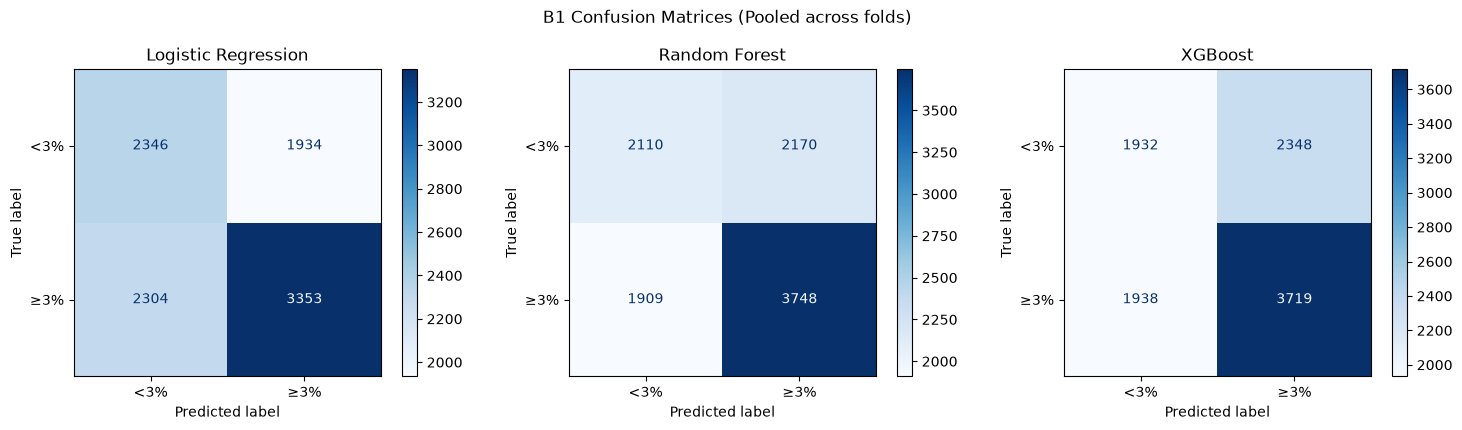

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, [("Logistic Regression", lr_clf),
                                 ("Random Forest", rf_clf),
                                 ("XGBoost", xgb_clf)]):
    true = np.array(r["true"])
    preds = np.array(r["preds"])
    ConfusionMatrixDisplay.from_predictions(true, preds, ax=ax, cmap="Blues",
                                            display_labels=["<3%", "≥3%"])
    ax.set_title(name)

plt.suptitle("B1 Confusion Matrices (Pooled across folds)", y=1.02)
plt.tight_layout()
plt.show()

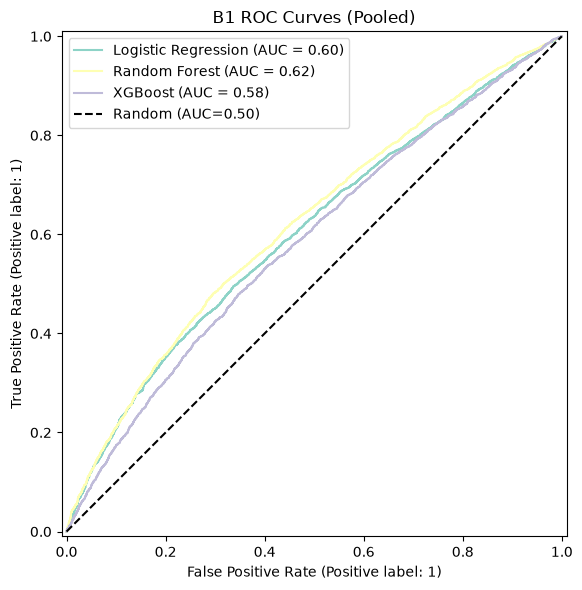

In [38]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, r in [("Logistic Regression", lr_clf),
                ("Random Forest", rf_clf),
                ("XGBoost", xgb_clf)]:
    true = np.array(r["true"])
    probs = np.array(r["probs"])
    RocCurveDisplay.from_predictions(true, probs, ax=ax, name=name)

ax.plot([0, 1], [0, 1], "k--", label="Random (AUC=0.50)")
ax.set_title("B1 ROC Curves (Pooled)")
ax.legend()
plt.tight_layout()
plt.show()

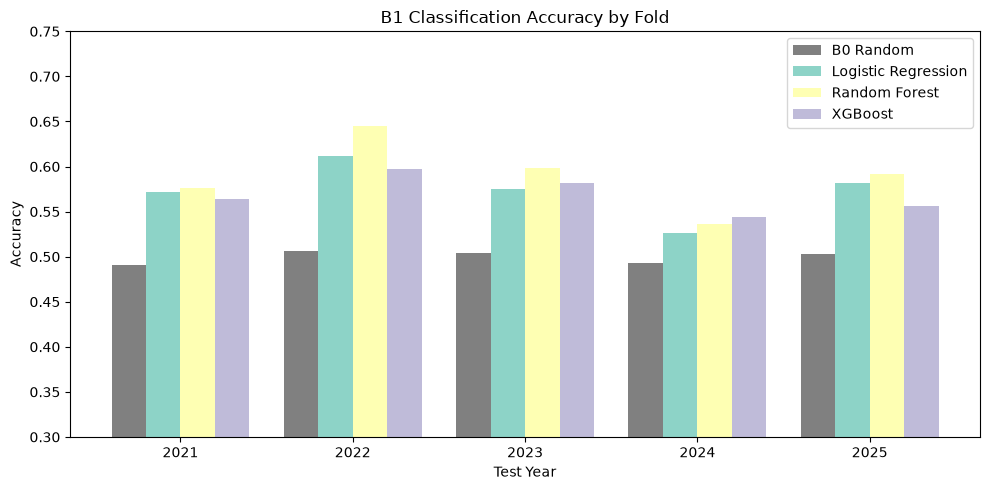

In [39]:
fold_years = [f["test_year"] for f in folds_data]
x = np.arange(len(fold_years))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, b0_clf["fold_acc"], width, label="B0 Random", color="gray")
ax.bar(x, lr_clf["fold_acc"], width, label="Logistic Regression")
ax.bar(x + width, rf_clf["fold_acc"], width, label="Random Forest")
ax.bar(x + 2*width, xgb_clf["fold_acc"], width, label="XGBoost")

ax.set_xticks(x + width/2)
ax.set_xticklabels(fold_years)
ax.set_xlabel("Test Year")
ax.set_ylabel("Accuracy")
ax.set_title("B1 Classification Accuracy by Fold")
ax.legend()
ax.set_ylim(0.3, 0.75)
plt.tight_layout()
plt.show()

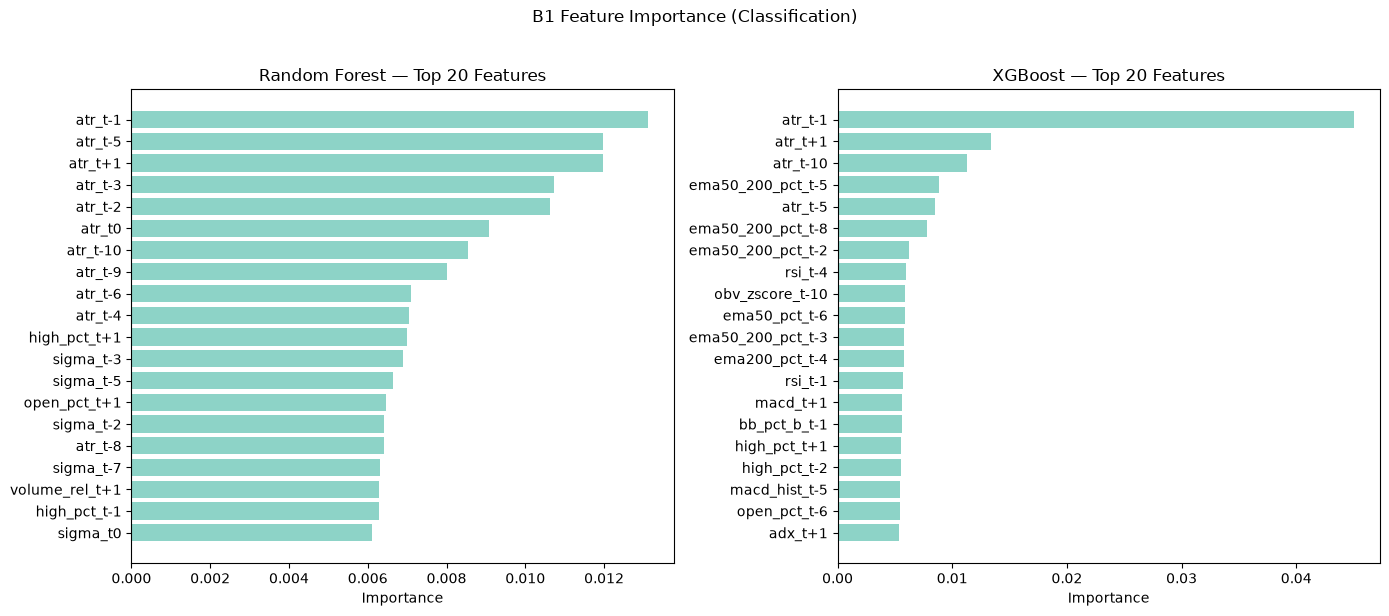

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
rf_imp = rf_clf_model.feature_importances_
rf_top_idx = np.argsort(rf_imp)[-20:]
axes[0].barh(np.array(feature_cols)[rf_top_idx], rf_imp[rf_top_idx])
axes[0].set_title("Random Forest — Top 20 Features")
axes[0].set_xlabel("Importance")

# XGBoost
xgb_imp = xgb_clf_model.feature_importances_
xgb_top_idx = np.argsort(xgb_imp)[-20:]
axes[1].barh(np.array(feature_cols)[xgb_top_idx], xgb_imp[xgb_top_idx])
axes[1].set_title("XGBoost — Top 20 Features")
axes[1].set_xlabel("Importance")

plt.suptitle("B1 Feature Importance (Classification)", y=1.02)
plt.tight_layout()
plt.show()

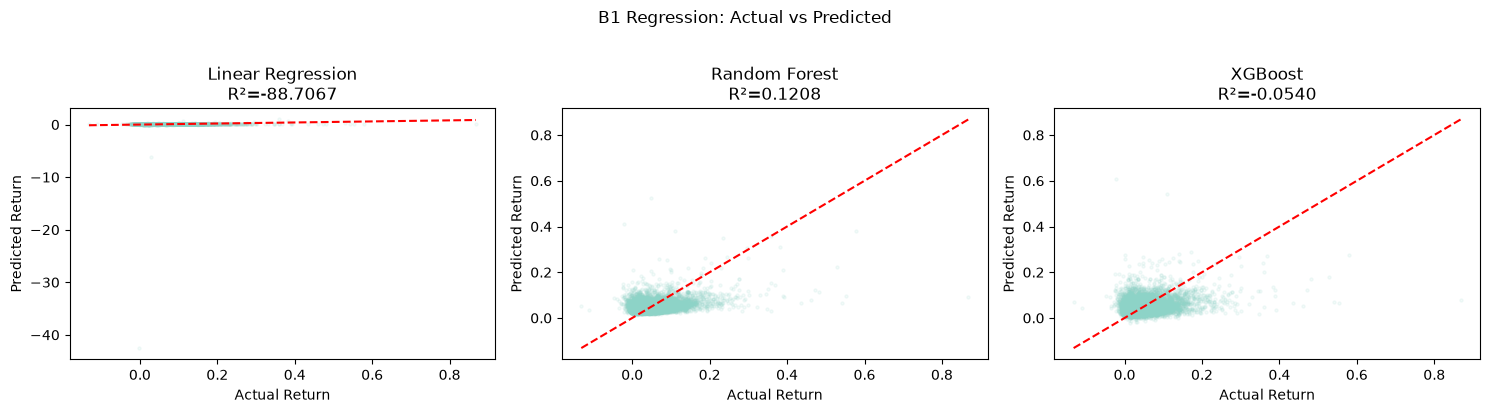

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, [("Linear Regression", linreg),
                                  ("Random Forest", rf_reg),
                                  ("XGBoost", xgb_reg)]):
    true = np.array(r["true"])
    preds = np.array(r["preds"])
    ax.scatter(true, preds, alpha=0.1, s=5)
    ax.plot([true.min(), true.max()], [true.min(), true.max()], "r--")
    ax.set_xlabel("Actual Return")
    ax.set_ylabel("Predicted Return")
    ax.set_title(f"{name}\nR²={r2_score(true, preds):.4f}")

plt.suptitle("B1 Regression: Actual vs Predicted", y=1.02)
plt.tight_layout()
plt.show()

In [42]:
os.makedirs("models", exist_ok=True)

for name, model in [("lr_clf", lr_model), ("linreg", linreg_model),
                     ("rf_clf", rf_clf_model), ("rf_reg", rf_reg_model),
                     ("xgb_clf", xgb_clf_model), ("xgb_reg", xgb_reg_model)]:
    joblib.dump(model, f"models/b1_{name}.pkl")
    print(f"Saved models/b1_{name}.pkl")

with open("models/b1_results.pkl", "wb") as f:
    pickle.dump({
        "clf": {"B0 Random": b0_clf, "Logistic Regression": lr_clf,
                "Random Forest": rf_clf, "XGBoost": xgb_clf},
        "reg": {"B0 Mean": b0_reg, "Linear Regression": linreg,
                "Random Forest": rf_reg, "XGBoost": xgb_reg},
    }, f)
print("Saved models/b1_results.pkl")

Saved models/b1_lr_clf.pkl
Saved models/b1_linreg.pkl
Saved models/b1_rf_clf.pkl
Saved models/b1_rf_reg.pkl
Saved models/b1_xgb_clf.pkl
Saved models/b1_xgb_reg.pkl
Saved models/b1_results.pkl
